# Import Libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('Resume Dataset.csv')

In [3]:
df.head()

,Category,Resume,Translated_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,Keterampilan * Bahasa Pemrograman: Python (pan...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...,Rincian Pendidikan \nMei 2013 hingga Mei 2017 ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...","Bidang Minat Pembelajaran Mendalam, Desain Sis..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Keterampilan â¢ R â¢ Python â¢ SAP HANA â¢...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad...","Rincian Pendidikan \nMCA YMCAUST, Faridabad, H..."


In [4]:
df = df.drop("Resume", axis=1)
df

,Category,Translated_Resume
0,Data Science,Keterampilan * Bahasa Pemrograman: Python (pan...
1,Data Science,Rincian Pendidikan \nMei 2013 hingga Mei 2017 ...
2,Data Science,"Bidang Minat Pembelajaran Mendalam, Desain Sis..."
3,Data Science,Keterampilan â¢ R â¢ Python â¢ SAP HANA â¢...
4,Data Science,"Rincian Pendidikan \nMCA YMCAUST, Faridabad, H..."
...,...,...
957,Testing,Keterampilan Komputer: â¢ Mahir dalam MS offi...
958,Testing,â€ Kemauan untuk menerima tantangan. â€ Berp...
959,Testing,"KETRAMPILAN PRIBADI â¢ Cepat belajar, â¢ Ber..."
960,Testing,KETRAMPILAN KOMPUTER & PENGETAHUAN PERANGKAT L...


In [7]:
df.columns = ["Category", "Resume"]

In [8]:
# OVERWRITE THE CHANGES TO CSV

df.to_csv("Resume Dataset Indonesian.csv", index=False)

In [9]:
df.shape

(962, 2)

In [10]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [11]:
pd.reset_option('display.max_colwidth')
df = df.dropna()

In [12]:
print(df)

         Category                                             Resume
0    Data Science  Keterampilan * Bahasa Pemrograman: Python (pan...
1    Data Science  Rincian Pendidikan \nMei 2013 hingga Mei 2017 ...
2    Data Science  Bidang Minat Pembelajaran Mendalam, Desain Sis...
3    Data Science  Keterampilan â¢ R â¢ Python â¢ SAP HANA â¢...
4    Data Science  Rincian Pendidikan \nMCA YMCAUST, Faridabad, H...
..            ...                                                ...
957       Testing  Keterampilan Komputer: â¢ Mahir dalam MS offi...
958       Testing  â€ Kemauan untuk menerima tantangan. â€ Berp...
959       Testing  KETRAMPILAN PRIBADI â¢ Cepat belajar, â¢ Ber...
960       Testing  KETRAMPILAN KOMPUTER & PENGETAHUAN PERANGKAT L...
961       Testing  Keahlian OS Windows XP/7/8/8.1/10 Database MYS...

[962 rows x 2 columns]


# Exploring Categories

In [13]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

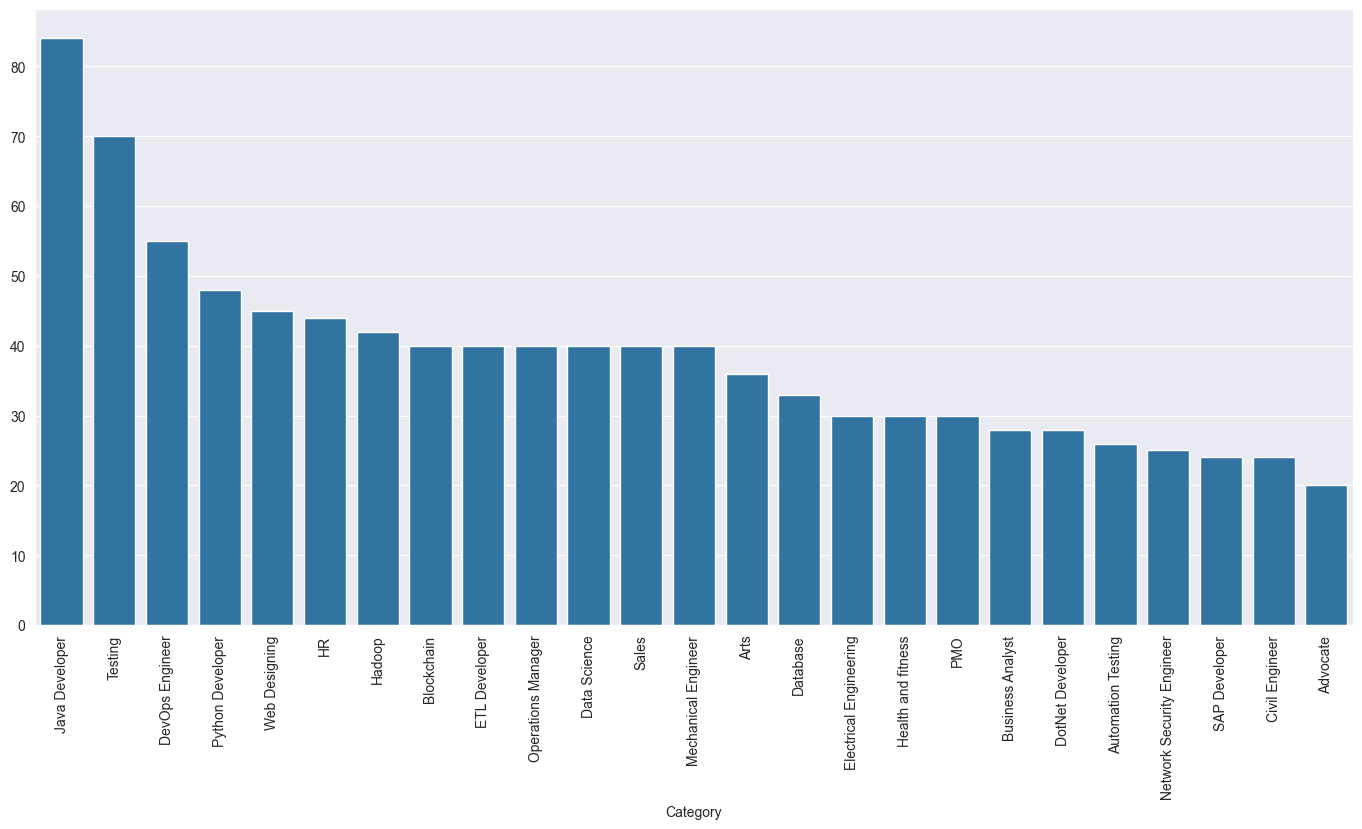

In [14]:
fig = plt.figure(figsize=(17,8))
sns.barplot(x=df['Category'].value_counts().index,
           y=df['Category'].value_counts().values)
plt.tick_params(axis ='x',rotation = 90)
plt.show()

In [15]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

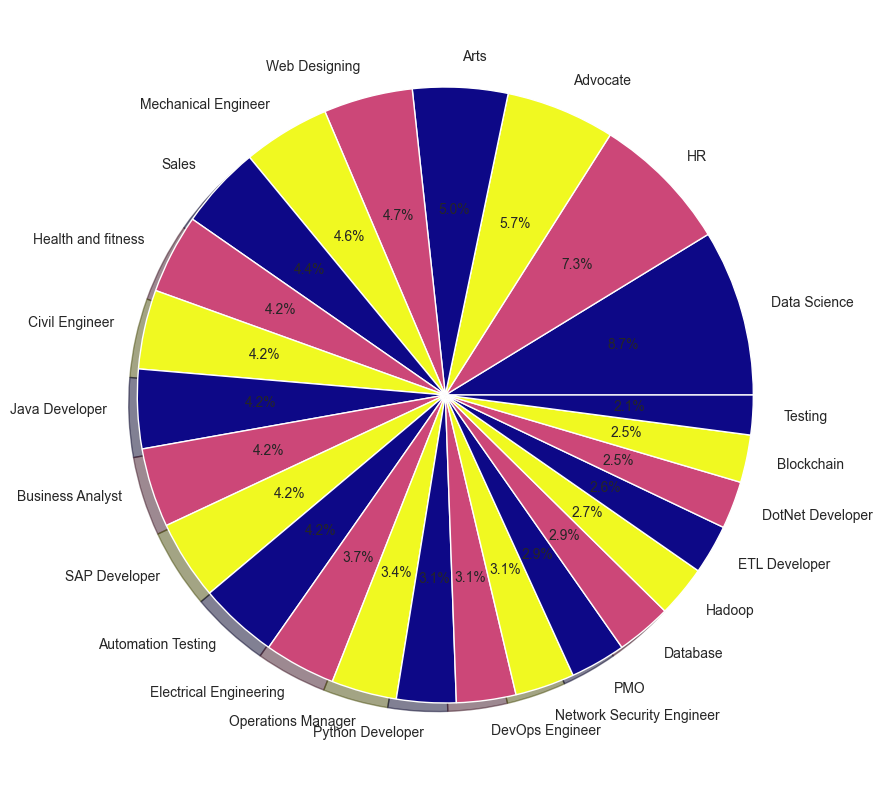

In [16]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

# Exploring Resume

In [17]:
df['Category'][0]

'Data Science'

In [18]:
df['Resume'][0]

'Keterampilan * Bahasa Pemrograman: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Pembelajaran mesin: Regresi, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Pohon, Teknik Boosting, Analisis Klaster, Penanaman Kata, Analisis Sentimen, Pemrosesan Bahasa Alami, Reduksi Dimensionalitas, Pemodelan Topik (LDA, NMF), PCA & Jaringan Syaraf. * Basis Data Visualisasi: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Lainnya: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, visi komputer - CV terbuka dan pemahaman tentang pembelajaran mendalam.Rincian Pendidikan \n\nRekan Penjaminan Ilmu Data \n\nRekan Penjaminan Ilmu Data - Ernst & Young LLP\nKeahlian Detail \nJAVASCRIPT- Pengalaman - 24 bulan\njQuery- Pengalaman - 24 bulan\nPython- Pengalaman - 24 bulanDetail Perusahaan \nperusahaan - Ernst & Young LLP\ndeskripsi - Investigasi Penipuan dan Sengketa Jami

# Balance Classes (Categories)

In [19]:
# Check the original category distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())

# Get the largest category size (i.e., the category with the maximum number of entries)
max_size = df['Category'].value_counts().max()

# Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
Sales                        84
Testing                      84
Mechan

C:\Users\Ali Novian\AppData\Local\Temp\ipykernel_2060\2902921212.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)


# Cleaning Data

In [20]:
# import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.tokenize import word_tokenize
# from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to C:\Users\Ali
[nltk_data]     Novian\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Ali
[nltk_data]     Novian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ali
[nltk_data]     Novian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Ali
[nltk_data]     Novian\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [21]:
import re

def clean_text(text):
    cleanText = text.lower()
    cleanText = re.sub(r'http\S+|www\S+', '', cleanText)
    cleanText = re.sub(r'\b(rt|cc)\b', '', cleanText)
    cleanText = re.sub(r'#\S+', '', cleanText)
    cleanText = re.sub(r'@\S+', '', cleanText)
    cleanText = re.sub(r'[!"#$%&\'()*+,-./:;<=>?@\[\]^_`{|}~]', ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7F]+', ' ', cleanText)
    cleanText = re.sub(r'\d+', '', cleanText)
    cleanText = re.sub(r'\s+', ' ', cleanText).strip()
    return cleanText

In [22]:
clean_text("Aku adalah seorang pembuat website @ali_novian https://alinovian.web.id/")

'aku adalah seorang pembuat website'

In [23]:
df['Resume']=df['Resume'].apply(clean_text)
df

,Category,Resume
0,Sales,detail pendidikan sarjana sarjana perdagangan ...
1,Database,keterampilan teknis basis data oracle rdbms g ...
2,Health and fitness,rincian pendidikan mei diploma pendidikan gizi...
3,Hadoop,kumpulan keterampilan teknis bahasa pemrograma...
4,Advocate,ketrampilan menguasai bahasa inggris sebagai p...
...,...,...
2095,Blockchain,keterampilan perangkat lunak bahasa c c java s...
2096,Arts,kualifikasi tambahan april kursus desain web d...
2097,Operations Manager,kompetensi utama manajemen multi operasi manaj...
2098,HR,pengetahuan komputer mahir dalam penggunaan da...


In [24]:
def tokenize_text(text):
  return word_tokenize(text)

# Terapkan fungsi tokenisasi pada setiap elemen di kolom 'content'
df['Resume'] = df['Resume'].apply(tokenize_text)
print(df)

                Category                                             Resume
0                  Sales  [detail, pendidikan, sarjana, sarjana, perdaga...
1               Database  [keterampilan, teknis, basis, data, oracle, rd...
2     Health and fitness  [rincian, pendidikan, mei, diploma, pendidikan...
3                 Hadoop  [kumpulan, keterampilan, teknis, bahasa, pemro...
4               Advocate  [ketrampilan, menguasai, bahasa, inggris, seba...
...                  ...                                                ...
2095          Blockchain  [keterampilan, perangkat, lunak, bahasa, c, c,...
2096                Arts  [kualifikasi, tambahan, april, kursus, desain,...
2097  Operations Manager  [kompetensi, utama, manajemen, multi, operasi,...
2098                  HR  [pengetahuan, komputer, mahir, dalam, pengguna...
2099                Arts  [kualifikasi, tambahan, april, kursus, desain,...

[2100 rows x 2 columns]


In [25]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi stop word remover dari Sastrawi
stop_factory = StopWordRemoverFactory()
stop_words_indonesian = set(stop_factory.get_stop_words())  # Daftar stop words bahasa Indonesia

# Fungsi untuk menghapus stopwords dari token-token kata
def remove_stopwords_sastrawi(tokens):
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words_indonesian]
    return filtered_tokens

# Terapkan fungsi pada kolom 'Resume' (diasumsikan sudah berupa token list)
df['Resume'] = df['Resume'].apply(remove_stopwords_sastrawi)

# Menampilkan hasil DataFrame
print(df)

                Category                                             Resume
0                  Sales  [detail, pendidikan, sarjana, sarjana, perdaga...
1               Database  [keterampilan, teknis, basis, data, oracle, rd...
2     Health and fitness  [rincian, pendidikan, mei, diploma, pendidikan...
3                 Hadoop  [kumpulan, keterampilan, teknis, bahasa, pemro...
4               Advocate  [ketrampilan, menguasai, bahasa, inggris, penu...
...                  ...                                                ...
2095          Blockchain  [keterampilan, perangkat, lunak, bahasa, c, c,...
2096                Arts  [kualifikasi, tambahan, april, kursus, desain,...
2097  Operations Manager  [kompetensi, utama, manajemen, multi, operasi,...
2098                  HR  [pengetahuan, komputer, mahir, penggunaan, das...
2099                Arts  [kualifikasi, tambahan, april, kursus, desain,...

[2100 rows x 2 columns]


In [26]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# Membuat stemmer dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(words):
  return [stemmer.stem(word) for word in words]

df.loc[:4, 'Resume'] = df.loc[:4, 'Resume'].apply(stemming)

df['Resume'] = df['Resume'].apply(lambda x: ' '.join(x))
df

,Category,Resume
0,Sales,detail didik sarjana sarjana dagang india seko...
1,Database,terampil teknis basis data oracle rdbms g g c ...
2,Health and fitness,rincian didik mei diploma didik gizi bengaluru...
3,Hadoop,kumpul terampil teknis bahasa pemrograman apac...
4,Advocate,ketrampilan kuasa bahasa inggris tutur asli ie...
...,...,...
2095,Blockchain,keterampilan perangkat lunak bahasa c c java s...
2096,Arts,kualifikasi tambahan april kursus desain web k...
2097,Operations Manager,kompetensi utama manajemen multi operasi manaj...
2098,HR,pengetahuan komputer mahir penggunaan dasar ms...


# Labelling

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [28]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [29]:
df.Category.unique()

array([22,  7, 14, 13,  0, 17, 18, 10,  6, 11, 20, 24,  1, 23,  5, 21,  2,
        3,  9, 19, 15,  4,  8, 16, 12])

In [30]:
# array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
#        'Mechanical Engineer', 'Sales', 'Health and fitness',
#        'Civil Engineer', 'Java Developer', 'Business Analyst',
#        'SAP Developer', 'Automation Testing', 'Electrical Engineering',
#        'Operations Manager', 'Python Developer', 'DevOps Engineer',
#        'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
#        'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
#       dtype=object)

# Vectorization

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Pastikan kolom 'Resume' sudah bersih dari stopwords dan telah dilakukan stemming
if 'Resume' not in df.columns:
    raise ValueError("Kolom 'Resume' tidak ditemukan dalam dataset.")

# TF-IDF Vectorization
tfidf = TfidfVectorizer()  # Tidak perlu mendefinisikan stop_words jika sudah dilakukan sebelumnya
tfidf.fit(df['Resume'])    # Mempelajari vocabularies dari teks yang sudah bersih
requiredText = tfidf.transform(df['Resume'])  # Menghasilkan matriks TF-IDF

# Output hasil
print("Dimensi matrix TF-IDF:", requiredText.shape)
print("Fitur yang dihasilkan:", tfidf.get_feature_names_out())

# Contoh matrix TF-IDF
print("Matrix TF-IDF:")
print(requiredText.toarray())

Dimensi matrix TF-IDF: (2100, 6578)
Fitur yang dihasilkan: ['aaa' 'aag' 'aakruti' ... 'zona' 'zookeeper' 'zz']
Matrix TF-IDF:
[[0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.0305771 ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 ...
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]]


# Splitting

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(requiredText, df['Category'], test_size=0.2, random_state=42)

In [34]:
X_train.shape

(1680, 6578)

In [35]:
X_test.shape

(420, 6578)

# Train model and print the classification report

In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.multiclass import OneVsRestClassifier

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train SVM model
svm_model = OneVsRestClassifier(SVC(probability=True, kernel='linear', random_state=42))
svm_model.fit(X_train, y_train_encoded)

# Predict and evaluate
y_pred_svm_encoded = svm_model.predict(X_test)
y_pred_svm = label_encoder.inverse_transform(y_pred_svm_encoded)

print("\nSVM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svm)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svm)}")


SVM Results:
Accuracy: 0.9976
Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0 

# Save Files

In [37]:
import pickle
pickle.dump(tfidf,open('tfidf_model.pkl','wb'))
pickle.dump(svm_model, open('classifier_svm.pkl', 'wb'))
pickle.dump(le, open("label_encoder.pkl",'wb'))

# Prediction System

In [38]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = clean_text(input_resume)

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svm_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

In [39]:
myresume = """Sarah Williams adalah seorang advokat yang berdedikasi dan terampil dengan lebih dari 10 tahun pengalaman dalam memberikan representasi hukum kepada klien di berbagai sektor, termasuk hukum pidana, litigasi perdata, dan hukum keluarga. Dengan pemahaman yang mendalam tentang prosedur hukum dan yurisprudensi, Sarah telah berhasil menangani banyak kasus di ruang sidang, menegosiasikan penyelesaian yang menguntungkan, dan memberikan nasihat hukum ahli kepada individu dan bisnis.

Ia memegang gelar sarjana hukum dari Universitas XYZ dan merupakan pengacara berlisensi yang berpraktik hukum di berbagai yurisdiksi. Sarah sangat antusias untuk memastikan keadilan ditegakkan dan berusaha keras untuk membuat proses hukum lebih mudah diakses oleh kliennya. Ia dikenal karena keterampilan penelitian dan analisisnya yang luar biasa, perhatian terhadap detail, dan komitmen untuk menegakkan hukum dengan integritas.

Keterampilan Utama:
- Hukum Pidana
- Litigasi Perdata
- Hukum Keluarga
- Hukum Kontrak
- Penelitian dan Penulisan Hukum
- Advokasi Ruang Sidang
- Konseling dan Nasihat Hukum
- Manajemen Hubungan Klien
- Kepatuhan Hukum dan Peraturan
- Negosiasi dan Penyelesaian

Sertifikasi dan Lisensi:
- Pengacara Berlisensi, XYZ Pengacara Negara
- Sertifikasi Hukum Pidana, Universitas XYZ

Pendidikan:
JD Hukum, Universitas XYZ, 2010-2013

Pengalaman Profesional:
- Advokat Senior di Firma Hukum ABC (2016-Sekarang)
- Advokat Asosiasi di DEF Legal Group (2013-2016)

Bahasa:
- Bahasa Inggris (Lancar)
- Bahasa Spanyol (Lirik)"""
result = pred(myresume)
print("Predicted category:", result)

Predicted category: Advocate


In [40]:
myresume = """
John Doe adalah seorang Network Security Engineer yang berpengalaman dengan lebih dari 7 tahun keahlian dalam merancang, mengimplementasikan, dan mengelola infrastruktur keamanan jaringan. Dengan spesialisasi dalam menjaga keamanan sistem jaringan yang penting, John telah bekerja dengan berbagai organisasi untuk melindungi dari ancaman dunia maya, pelanggaran data, dan akses yang tidak sah. Ia ahli dalam menerapkan firewall, sistem deteksi intrusi (IDS), VPN, dan alat pemantauan jaringan untuk memastikan integritas dan keamanan jaringan.

John memiliki gelar dalam Ilmu Komputer dan sertifikasi dalam beberapa domain keamanan dunia maya, termasuk Certified Information Systems Security Professional (CISSP), Certified Ethical Hacker (CEH), dan Cisco Certified Network Associate (CCNA). Ia memiliki pengalaman yang luas dalam memecahkan masalah dan mengatasi kerentanan jaringan, dan telah memainkan peran penting dalam melakukan audit keamanan dan penilaian risiko.

Keahlian Utama:
- Arsitektur Keamanan Jaringan
- Manajemen dan Konfigurasi Firewall
- Sistem Deteksi dan Pencegahan Intrusi (IDS/IPS)
- Jaringan Privat Virtual (VPN)
- Audit Keamanan dan Penilaian Risiko
- Respons Insiden Keamanan Dunia Maya
- Pemantauan Jaringan dan Analisis Lalu Lintas
- Penilaian Kerentanan dan Pengujian Penetrasi
- Enkripsi Data dan Komunikasi Aman

Sertifikasi:
- CISSP (Profesional Keamanan Sistem Informasi Bersertifikat)
- CEH (Peretas Etis Bersertifikat)
- CCNA (Rekan Jaringan Bersertifikat Cisco)
- CompTIA Security+

Pendidikan:
Sarjana Ilmu Komputer, Universitas XYZ, 2012-2016

Pengalaman Profesional:
- Insinyur Keamanan Jaringan di ABC Corp (2016-Sekarang)
- Spesialis Keamanan TI di DEF Solutions (2014-2016)

Bahasa:
- Bahasa Inggris (Lancar)
- Bahasa Prancis (Menengah)
"""
result = pred(myresume)
print("Predicted category:", result)

Predicted category: Network Security Engineer


In [41]:
myresume = """Jane Smith adalah pelatih pribadi bersertifikat dengan pengalaman lebih dari 5 tahun dalam membantu individu mencapai sasaran kebugaran mereka. Dengan spesialisasi dalam penurunan berat badan, latihan kekuatan, dan pengondisian olahraga, Jane telah mengembangkan rutinitas latihan yang dipersonalisasi untuk klien dari segala usia dan tingkat kebugaran. Ia memiliki pengetahuan luas dalam ilmu gizi dan olahraga, dan menggunakannya untuk membuat program kesehatan dan kebugaran holistik yang disesuaikan dengan kebutuhan individu.

Jane memiliki gelar dalam Ilmu Olahraga dan merupakan pelatih bersertifikat melalui National Academy of Sports Medicine (NASM). Ia telah bekerja dengan atlet, manula, dan individu dengan kondisi kesehatan kronis, membantu mereka meningkatkan kesejahteraan fisik dan kualitas hidup secara keseluruhan.

Keahliannya meliputi:
- Penurunan Berat Badan dan Komposisi Tubuh
- Latihan Kekuatan dan Latihan Ketahanan
- Pengondisian Kardio
- Pelatihan Nutrisi dan Perencanaan Makan
- Pencegahan dan Rehabilitasi Cedera
- Pelatihan Gerakan Fungsional dan Fleksibilitas
- Kelas Kebugaran Kelompok

Sertifikasi:
- Pelatih Pribadi Bersertifikat, NASM
- Bersertifikat CPR dan Pertolongan Pertama
- Instruktur Yoga (200 Jam Sertifikasi)

Pendidikan:
Sarjana Sains Olahraga, Universitas ABC, 2014-2018

Pengalaman Kerja:
- Pelatih Pribadi di XYZ Fitness Gym (2018-Sekarang)
- Pelatih Kebugaran di Wellness Center (2016-2018)

Bahasa:
- Bahasa Inggris (Lancar)
- Bahasa Spanyol (Lirik)
"""
result = pred(myresume)
print("Predicted category:", result)

Predicted category: Health and fitness


In [42]:
myresume = """Nama: John Doe

Alamat: Jl. Contoh No. 123, Jakarta

Email: johndoe@example.com

No Telepon: 08123456789

Summary
John Doe memiliki pengalaman lebih dari lima tahun sebagai Data Scientist. Beliau ahli dalam menganalisis data dan membangun model prediksi yang akurat untuk membantu perusahaan mengambil keputusan strategis. John memiliki latar belakang pendidikan yang kuat dalam ilmu komputer dan matematika, dan memiliki sertifikasi terkait ilmu data.

Pengalaman Kerja
Data Scientist, PT ABC Teknologi, Jakarta (2018 - Sekarang)
Senior Data Analyst, PT XYZ Solusi, Jakarta (2015 - 2018)
Pendidikan
Sarjana Komputer, Universitas PQR, Jakarta (2011 - 2015)
Magister Ilmu Data, Universitas UVW, Jakarta (2015 - 2017)
Keterampilan
SQL
R
Python
Machine Learning
Statistik
Sertifikasi
Certified Data Scientist (CDS)
Microsoft Certified: Azure Data Scientist Associate
Bahasa
Inggris - Lancar
Bahasa Indonesia - Lancar
"""

# Uji model dengan resume yang berfokus pada Data Science

result = pred(myresume)
print("Predicted category:", result)

Predicted category: Data Science
